In [1]:
import numpy as np  # generic math functions
import scipy.linalg as spla
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

SMALL_SIZE = 20
MEDIUM_SIZE = 24
BIGGER_SIZE = 26
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=SMALL_SIZE)

plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the Xtick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the Ytick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # fontsize of the legend 
plt.rc('figure', titlesize=SMALL_SIZE)  # fontsize of the figure title

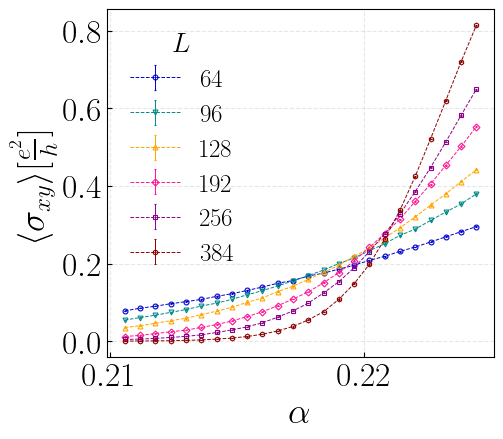

In [4]:
plt.gca().set_box_aspect(0.9)

markerband = ['o', 'v', '^', 'D', 's', 'h']
colorband=['mediumblue', 'darkcyan', 'orange', 'deeppink', 'darkmagenta', 'darkred']

for il, L in enumerate([64, 96, 128, 192, 256, 384]):

    data=np.loadtxt('/Users/nabaprakash/Downloads/adhip fit/sigmaxy_L'+str(L)+'.txt')
    plt.errorbar((data[:,0]), data[:,1], yerr=data[:,2], marker=markerband[il], markersize=3.5, 
                 color=colorband[il], mew=0.8, mfc='none', linestyle="--", 
        capsize=1, capthick = .4, linewidth=0.7, label=L,)
    
    # pl.errorbar((lndata[indx, 0]-0.8683)*L**(1/1.62), lndata[indx, 1], fmt='o', ms=3, yerr=lndata[indx,2], 
    # capsize=1.2)



plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle \sigma_{xy} \rangle \bigg[\frac{e^2}{h}\bigg]$")
#plt.xticks([0.825, 0.85, 0.875, 0.9])
plt.legend(title="$L$", fontsize=18, loc = "upper left", frameon = False)
plt.tick_params(direction='in')
plt.grid(True, linestyle="--", alpha=0.3)
#plt.axvline(-0.294)
plt.tight_layout()
plt.show()
#plt.savefig("AI_CI_raw_p0p4.pdf")

96
Best nu from RMSE = 1.0430
Best nu from GOF  = 1.0670
Best nu from chi2 = 1.0340
Best nu from R2 = 1.0430

At minimum RMSE:
nu = 1.04300
RMSE = 1.49611793e-03
R2 = 0.99975849
GOF = 5.93722245e-03
GOF/N = 6.18460671e-05
chi2 = 658.94669953
chi2_red = 7.48803068

Best-fit parameters:
[ 3.88955372e-01  1.08992954e-01  1.06066750e-02  3.74750661e-04
 -2.85044371e+00  1.49275742e-01  2.21446872e-01  1.04300000e+00]


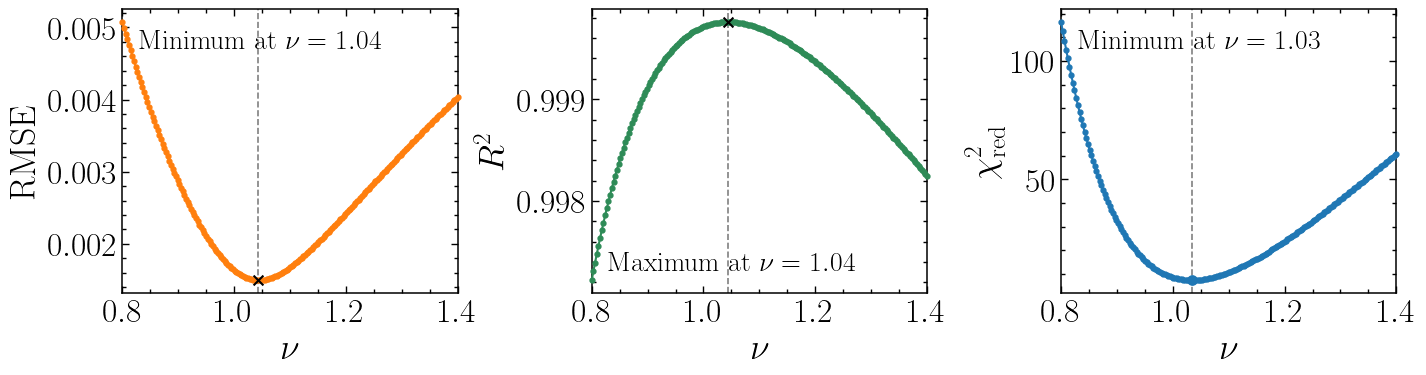

In [6]:
import numpy as np

M_arr = np.array([64, 96, 128, 192, 256, 384])

xx_list = []
conductance_list = []
sem_list = []

amx = 4
amn = 4

for L in M_arr:
    data=np.loadtxt('/Users/nabaprakash/Downloads/adhip fit/sigmaxy_L'+str(L)+'.txt')

    # Construct cdata exactly as in your original code
    cdata = np.c_[
        np.r_[data[:, 0]],
        np.r_[data[:, 1]],
        np.r_[data[:, 2]]
    ]

    # Sort according to xx
    cdata = cdata[np.argsort(cdata[:, 0])]
    
    # Store the three columns
    xx_list.append((cdata[:, 0])[amx: -amn]) #
    conductance_list.append((cdata[:, 1])[amx: -amn])
    sem_list.append((cdata[:, 2])[amx: -amn])

xx = np.array((xx_list[0]))
average_conductance = np.array(conductance_list)
sem = np.array(sem_list)


# Create the extended length array
LData = np.kron(np.ones(len(xx[:]) ) , M_arr[:] ) 
# LData_full = np.kron( np.ones(len(dens_arr_full[:]) ) , L_arr[:] ) 

Rho_Data = np.kron(xx[:],np.ones(len(M_arr[:])) )
# Rho_Data_full = np.kron( dens_arr_full[:],np.ones(len(L_arr[:])) )

avg_g_flat = average_conductance[:,:].T.flatten()
# avg_g_flat_full = data_arr_full.T.flatten()

#LOG DATA
#log_avg_g_flat = log_data_arr_full.T.flatten()

def fit_fun(data, a0, a1, a2, a3, b0, b1, rc, nu):
    
    L   = data[0]    
    rho = data[1] 

    rho_n = ((rho-rc)/rc)

    x = rho_n*(L**(1/nu))

    return a0 + a1*x  + a2*x**2  +  a3*x**3 + b0*L**(-0.7) * (1 +  b1*x)

y = avg_g_flat
sigma = sem.T.flatten()
p0 = [1, 1, 1, 0.1, 1.12, 0.22, 0.221, 1]
data = [LData, Rho_Data]

N = len(y)
k = len(p0)
dof = N - k
print(N)
nu_values = np.linspace(0.8, 1.4, 201)  

rmse_values = []
r2_values = []

GOF_values = []
GOF_per_point_values = []

chi2_values = []
chi2_red_values = []

fit_parameters = []

for nu in nu_values:
    # Function with nu fixed
    def fit_nu_fixed(data, a0, a1, a2, a3, a4, a5, rc):
        return fit_fun(data, a0, a1, a2, a3, a4, a5, rc, nu)

    p0 = np.array([1, 1, 1, 0.1, 1.12, 0.22, 0.221])

    try:
        popt, pcov = curve_fit(fit_nu_fixed, data, avg_g_flat, maxfev=100000, p0=p0)

        F = fit_nu_fixed(data, *popt)
        residual = F - y

        # RMSE
        rmse = np.sqrt(np.mean(residual**2))
        rmse_values.append(rmse)

        # R^2
        SS_res = np.sum(residual**2)
        SS_tot = np.sum((y - np.mean(y))**2)
        R2 = 1 - SS_res / SS_tot
        r2_values.append(R2)

        # GOF
        GOF = np.sum(residual**2 / y)
        GOF_values.append(GOF)
        GOF_per_point_values.append(GOF / N)

        # chi2 = sum [(F_i-g_i)/SEM_i]^2
        chi2 = np.sum((residual / sigma)**2)
        chi2_values.append(chi2)
        chi2_red_values.append(chi2 / dof)

        # Store parameters
        fit_parameters.append(np.append(popt, nu))

    except (RuntimeError, ValueError):
        rmse_values.append(np.nan)
        r2_values.append(np.nan)

        GOF_values.append(np.nan)
        GOF_per_point_values.append(np.nan)

        chi2_values.append(np.nan)
        chi2_red_values.append(np.nan)

        fit_parameters.append(None)


rmse_values = np.array(rmse_values)
r2_values = np.array(r2_values)

GOF_values = np.array(GOF_values)
GOF_per_point_values = np.array(GOF_per_point_values)

chi2_values = np.array(chi2_values)
chi2_red_values = np.array(chi2_red_values)


# Best values
best_rmse_index = np.nanargmin(rmse_values)
best_gof_index = np.nanargmin(GOF_values)
best_chi2_index = np.nanargmin(chi2_red_values)
best_r2_index = np.nanargmax(r2_values)


print(f"Best nu from RMSE = " f"{nu_values[best_rmse_index]:.4f}")
print(f"Best nu from GOF  = " f"{nu_values[best_gof_index]:.4f}")
print(f"Best nu from chi2 = " f"{nu_values[best_chi2_index]:.4f}")
print(f"Best nu from R2 = " f"{nu_values[best_r2_index]:.4f}")

print("\nAt minimum RMSE:")
print(f"nu = {nu_values[best_rmse_index]:.5f}")
print(f"RMSE = {rmse_values[best_rmse_index]:.8e}")
print(f"R2 = {r2_values[best_rmse_index]:.8f}")
print(f"GOF = {GOF_values[best_rmse_index]:.8e}")
print(f"GOF/N = {GOF_per_point_values[best_rmse_index]:.8e}")
print(f"chi2 = {chi2_values[best_rmse_index]:.8f}")
print(f"chi2_red = {chi2_red_values[best_rmse_index]:.8f}")

print("\nBest-fit parameters:")
print(fit_parameters[best_rmse_index])


nu_rmse = nu_values[best_rmse_index]
nu_r2   = nu_values[best_r2_index]
nu_gof  = nu_values[best_gof_index]
nu_chi2  = nu_values[best_chi2_index]


fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

# RMSE
ax = axes[0]
ax.plot(nu_values, rmse_values, 'o-', color='tab:orange', ms=3.5, lw=1.5, zorder=5, clip_on=False)
ax.axvline(nu_rmse, ls='--', lw=1.2, color='gray')
ax.scatter(nu_rmse, rmse_values[best_rmse_index], marker='x', s=50, zorder=5, color='k')

ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'RMSE')
ax.text(0.05, 0.93, rf'Minimum at $\nu={nu_rmse:.2f}$', transform=ax.transAxes, va='top')
#ax.set_title('(a) RMSE', pad=8)

# R^2
ax = axes[1]
ax.plot(nu_values, r2_values, 'o-', color='seagreen', ms=3.5, lw=1.5, zorder=5, clip_on=False)
ax.axvline(nu_r2, ls='--', lw=1.2, color='gray')
ax.scatter(nu_r2, r2_values[best_r2_index], marker='x', s=50, zorder=5, color='k')

ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$R^2$')
ax.text(0.05, 0.08,rf'Maximum at $\nu={nu_r2:.2f}$',transform=ax.transAxes)
#ax.set_title(r'(b) $R^2$', pad=8)


# GOF
ax = axes[2]
ax.plot(nu_values, chi2_red_values, 'o-', ms=3.5, lw=1.5, zorder=5, clip_on=False)
ax.axvline(nu_chi2, ls='--', lw=1.2, color='gray')
ax.scatter(nu_chi2, chi2_red_values[best_chi2_index], s=45, zorder=5)

ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$\chi^{2}_{\rm{red}}$')

ax.text(0.05, 0.93, rf'Minimum at $\nu={nu_chi2:.2f}$', transform=ax.transAxes, va='top')
#ax.set_title('(c) GOF', pad=8)


for ax in axes:
    ax.set_xlim(nu_values.min(), nu_values.max())
    ax.tick_params(which='both', direction='in', top=True, right=True, length=5, width=1)
    ax.minorticks_on()
    ax.tick_params(which='minor', direction='in', top=True, right=True, length=3)
    for spine in ax.spines.values():
        spine.set_linewidth(1.1)

# Layout
plt.subplots_adjust(left=0.07, right=0.98, bottom=0.17, top=0.88, wspace=0.4)

#plt.savefig('GOF_RMSE_R2_vs_nu_AICI.pdf', bbox_inches='tight')
plt.show()

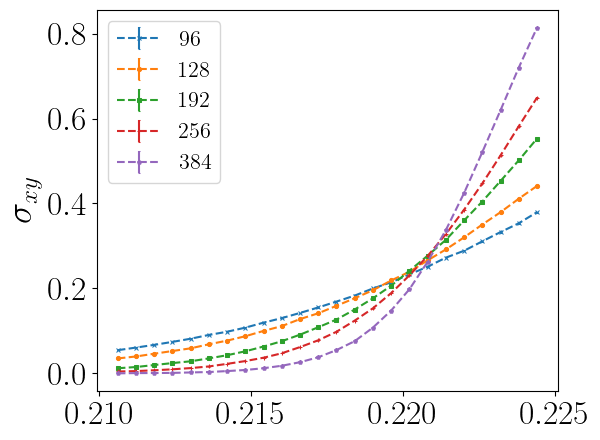

(17,)


In [8]:
def cfit(x, *aa):

    larr=x[0]
    marr=x[1]
    
    a0 = aa[0]
    a1 = aa[1]
    a2 = aa[2]
    a3 = aa[3]
    # 
    
    b0 = aa[4]
    b1 = aa[5]
    
    mc = aa[6]
    nu = aa[7]
    # y  = aa[8] ##<--- fixed it by hand close to 1. 
    
    mred = (marr-mc)/mc

    xx = larr**(1/nu) * mred

    return a0 + a1*xx  + a2*xx**2  +  a3*xx**3 + b0*larr**(-0.7) * (1 +  b1*xx)

fmm=['x', 'o', 's', '+', 'p', 'd', '1']
alph_arr=np.round(np.arange(0.2106, 0.225, 0.0006),4) ## 24 points

Ll=np.array([96, 128, 192, 256, 384])

sxy=np.zeros((len(Ll), len(alph_arr)))
sxy_err=np.zeros((len(Ll), len(alph_arr)))


for il, L in enumerate(Ll):

    data=np.loadtxt('/Users/nabaprakash/Downloads/adhip fit/sigmaxy_L'+str(L)+'.txt')

    # print(il)
    sxy[il] = data[:, 1]
    sxy_err[il] = data[:, 2]

    
    plt.errorbar((data[:,0]-0.0)*L**(0/1.11), data[:, 1], fmt=fmm[il], ls='--', \
                ms=3, yerr=data[:,2], capsize=1., \
                alpha=1, label=L, mfc=None, mew=0.75)
    
    # pl.errorbar((lndata[indx, 0]-0.8683)*L**(1/1.62), lndata[indx, 1], fmt='o', ms=3, yerr=lndata[indx,2], capsize=1.2)

# pl.axvline(0, ls='--')
#pl.semilogy()
plt.ylabel(r'$\sigma_{xy}$')
# pl.xlabel(r'$(p-0.868) \cdot L^{1/2.1}$')
plt.tight_layout()
# pl.semilogx()
plt.legend(fontsize=16)
# pl.savefig('collapse_vs_p.pdf')
plt.show()

ap=5
pi=2

ncval=alph_arr[ap:-pi]

print(ncval.shape)

Ln = np.kron(Ll, np.ones(ncval.size))
dn = np.kron(np.ones(Ll.size),ncval)

# print(Ln, dn)

xData=np.array([Ln, dn])

yData1=sxy[:,ap:-pi]
errE1=sxy_err[:, ap:-pi]

yData=sxy[:,ap:-pi].flatten()
errE=sxy_err[:, ap:-pi].flatten()


[ 3.98323408e-01  1.27566885e-01  1.42510328e-02  5.80223857e-04
 -2.97076032e+00  1.64430258e-01  2.21546176e-01  1.07569363e+00] [4.86561735e-06 8.70287586e-06 4.10427039e-07 1.52302594e-09
 2.30261117e-03 4.60643560e-05 1.49012165e-10 2.18628737e-05]


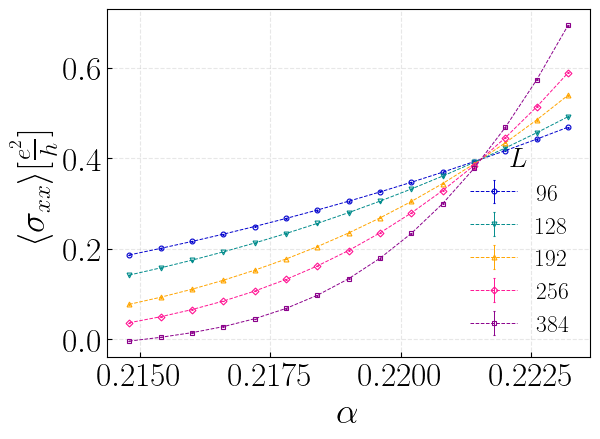

In [9]:
popt, pcov = curve_fit(cfit, xData, yData, sigma=errE, \
                       maxfev=int(1e5), absolute_sigma=True, p0=[1, 1, 1, 0.1, 1.12, 0.22, 0.221, 1])

lent = 17

corrected_data = cfit(xData, *popt) - cfit(xData, *(np.array([0, 0, 0, 0, -2.97076046e+00, 
                                                   1.64430185e-01, 2.21546176e-01, 1.07569357e+00])))

for il, L in enumerate(Ll):

    plt.errorbar((ncval)[2:], (corrected_data[il*lent:(il*lent)+lent])[2:], yerr=errE1[il][2:], marker=markerband[il], 
                 markersize=3.5, color=colorband[il], mew=0.8, mfc='none', linestyle="--", 
        capsize=1, capthick = .4, linewidth=0.7, label=L)
    
    
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle \sigma_{xx} \rangle \bigg[\frac{e^2}{h}\bigg]$")
#plt.xticks([0.825, 0.85, 0.875, 0.9])
plt.legend(title="$L$", fontsize=17,  loc = "lower right",frameon = False)
plt.tick_params(direction='in')
plt.grid(True, linestyle="--", alpha=0.3)
#plt.axvline(-0.294)
plt.tight_layout()


#plt.plot(dn, cfit(xData, *popt), 'x', ms=3, color='r')

#print(cfit(xData, *popt))

print(popt, np.diag(pcov))
# pl.semilogy()
plt.show()

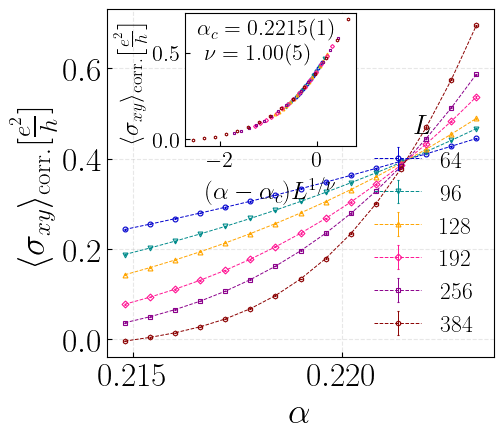

In [23]:
Ll=np.array([64, 96, 128, 192, 256, 384])

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.gca().set_box_aspect(0.9)

# ---------- MAIN PLOT: raw data (with error bars) ----------
colorband=['mediumblue', 'darkcyan', 'orange', 'deeppink', 'darkmagenta', 'darkred']
markerband = ['o', 'v', '^', 'D', 's', 'h']
#Y = fit_fun(data, *popt).reshape(len(xx), len(L_arr))

#for i in range(len(L_arr)-1):
    #plt.plot(xx, Y[:, i+1], "--", color=colorband[i], lw=0.7)


for il, L in enumerate(Ll):

    plt.errorbar((ncval)[2:], (corrected_data[il*lent:(il*lent)+lent])[2:], yerr=errE1[il][2:], marker=markerband[il], 
                 markersize=3.5, color=colorband[il], mew=0.8, mfc='none', linestyle="--", 
        capsize=1, capthick = .4, linewidth=0.7, label=L)
    
    
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle \sigma_{xy} \rangle_{\rm{corr.}} \bigg[\frac{e^2}{h}\bigg]$")
#plt.xticks([0.825, 0.85, 0.875, 0.9])
plt.legend(title="$L$", fontsize=17,  loc = "lower right",frameon = False)
plt.tick_params(direction='in')
plt.grid(True, linestyle="--", alpha=0.3)
#plt.axvline(-0.294)
plt.tight_layout()

# Add annotation in main plot
#plt.text(
    #0.05, 0.45,   # (x,y) in axis fraction coords
    #r"$M = 1,\; p = 0.6$",
    #transform=plt.gca().transAxes, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

# ---------- INSET PLOT: scaling collapse (no error bars) ----------
ax_inset = inset_axes(plt.gca(), width="52%", height="45%", loc="upper left",bbox_to_anchor=(0.2, 0.14, 0.85, 0.85), 
                      borderpad=0.01, bbox_transform=plt.gca().transAxes)

ac = 0.2215   # critical alpha
nu = 1.00
for il, L in enumerate(Ll):

    ax_inset.plot(((ncval-ac)*L**(1/nu))[2:], (corrected_data[il*lent:(il*lent)+lent])[2:], 
        marker=markerband[il], markersize=2, color=colorband[il], mew=0.8, mfc='none', linestyle="None")
    

ax_inset.set_xlabel(r"$(\alpha-\alpha_c)L^{1/\nu}$", fontsize=18)
ax_inset.set_ylabel(r"$\langle \sigma_{xy} \rangle_{\rm{corr.}} \bigg[\frac{e^2}{h}\bigg]$", fontsize=18)
#ax_inset.set_xlim(-0.7, 0.7)
#ax_inset.set_ylim(0.2, 0.75)

ax_inset.tick_params(direction='in', axis='both', which='major', labelsize=16)
#ax_inset.grid(True, alpha=0.3)

# Add text with α_c and ν inside inset
ax_inset.text(
    0.12, 0.65, 
    rf"$\nu= {nu:.2f}(5)$",
    transform=ax_inset.transAxes,
    fontsize=16,
    bbox=dict(facecolor="none", edgecolor="none"))
ax_inset.text(
    0.07, 0.84, 
    rf"$\alpha_c = {ac:.4f}(1)$",
    transform=ax_inset.transAxes,
    fontsize=16,
    bbox=dict(facecolor="none", edgecolor="none"))

# Save if needed
#plt.tight_layout()
#plt.savefig("AI_CI_corrected_p0p4.pdf")
plt.show()
